Import libraries 

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import seaborn as sns
import hilearn
import scanpy as sc
from scipy.sparse import issparse
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict

Load Datasets

In [2]:
atlas_adata = sc.read("C:\\Users\\jysje\\Downloads\\CountAdded_PIP_T_object_for_cellxgene.h5ad")
abT_adata = sc.read("C:\\Users\\jysje\\Downloads\\adata_TILC_TCR_onlyseq.h5ad")
gdT_adata = sc.read("C:\\Users\\jysje\\Downloads\\adata_TILC_TCRgd_onlyseq.h5ad")
SONG_base = Path(r"C:\Users\jysje\Downloads\analysis\hd_rna_abtcr_gdtcr_SONG\hd_rna_abtcr_gdtcr_SONG")

In [ ]:
DATA_DIR = Path("data")

atlas_adata = sc.read(DATA_DIR / "CountAdded_PIP_T_object_for_cellxgene.h5ad")
abT_adata = sc.read(DATA_DIR / "adata_TILC_TCR_onlyseq.h5ad")
gdT_adata = sc.read(DATA_DIR / "adata_TILC_TCRgd_onlyseq.h5ad")

SONG_base = DATA_DIR / "hd_rna_abtcr_gdtcr_SONG"

Global Configuration & Palettes

In [3]:
receptor_subtype_palette = {
    'TRG+TRD': '#b93932',  
    'TRA+TRB': '#4c76af', 
    'ambiguous': '#9c4bf3', 
    'multichain': '#5c9b6d',  
    'no IR': '#dde0e5'
}

t_cell_type_palette = {
    'gdT': '#b93932',  
    'abT': '#4c76af', 
    'Both': '#5c9b6d',  
    'None': '#e38536'   
}

palette_split = {
    'Train': '#f2c94c',  
    'Test atlas': '#7b4ab2' 
}

In [4]:
def round_label(label):
    match = re.search(r"\(([\d\.]+)%\)", label)
    if match:
        value = float(match.group(1))
        return label.replace(match.group(0), f"({value:.1f}%)")
    return label

Atlas Dataset Quality Assessment

In [5]:
atlas_adata.X = atlas_adata.layers["counts"].copy()

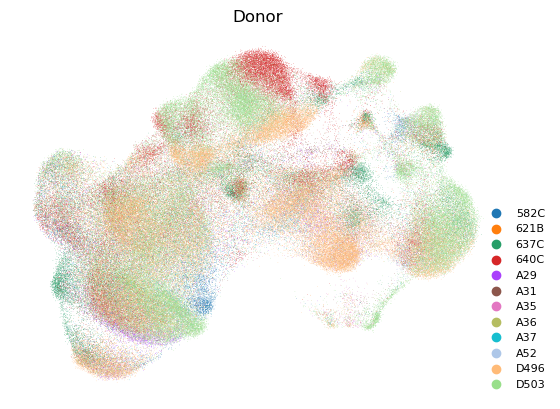

In [6]:
ax = sc.pl.umap(atlas_adata, 
           color="Donor", 
           legend_fontsize=8, 
           legend_fontoutline=0,
           frameon=False, 
           show=False
           )

ax.legend(
    loc='lower right',
    bbox_to_anchor=(1.1, 0.0), 
    fontsize=8,
    frameon=False
)
plt.show()

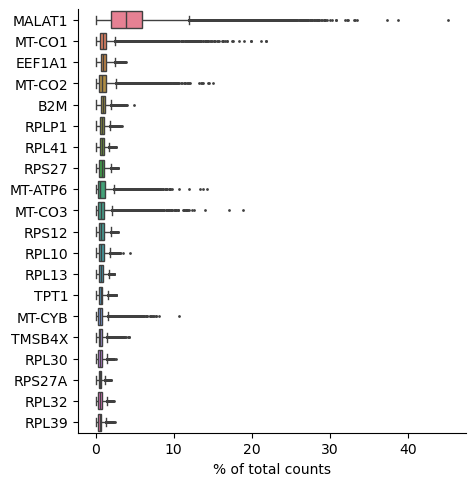

In [7]:
atlas_adata.var_names_make_unique() 
ax = sc.pl.highest_expr_genes(atlas_adata, n_top=20, show=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

In [8]:
atlas_adata.var["mt"] = atlas_adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(atlas_adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

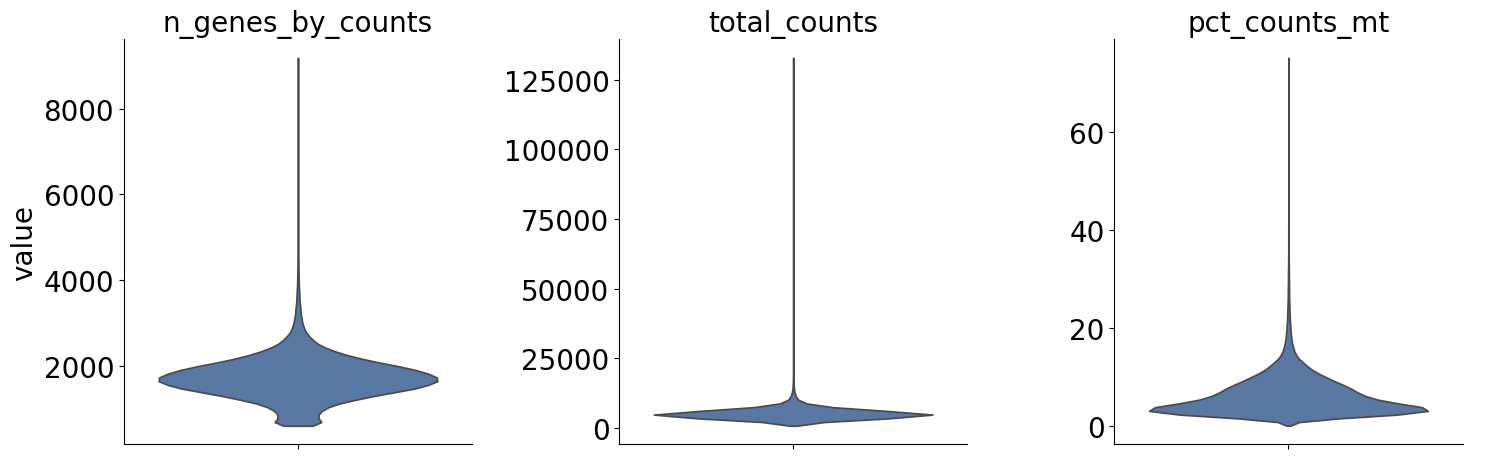

In [9]:
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20
})

sc.pl.violin(
    atlas_adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    stripplot=False,
    multi_panel=True,
    color='#4c76af'
)

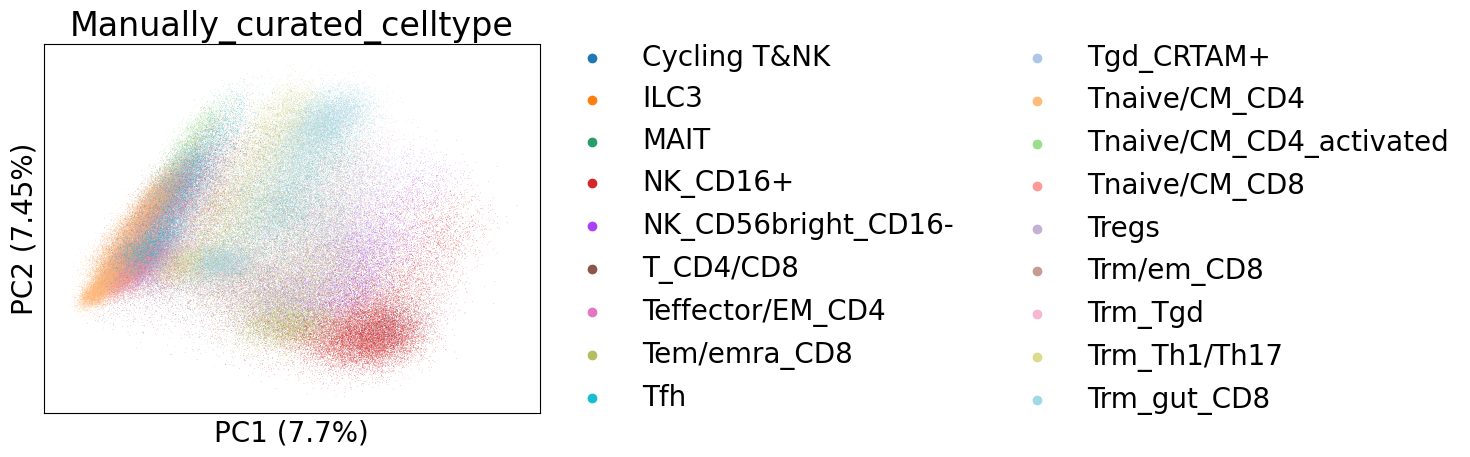

In [10]:
sc.pp.normalize_total(atlas_adata, target_sum=1e4)
sc.pp.log1p(atlas_adata)

sc.pp.highly_variable_genes(
    atlas_adata,
    layer="counts",
    n_top_genes=2000,
    flavor="seurat_v3"
)

sc.pp.pca(atlas_adata, svd_solver="arpack")

sc.pl.pca(atlas_adata, annotate_var_explained=True, color="Manually_curated_celltype")

GEX + TCRab & GEX + TCRgd data Quality Assessment

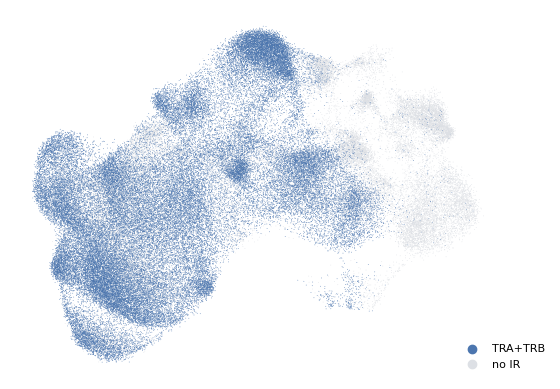

In [11]:
gd_ax = sc.pl.umap(
    abT_adata, 
    color='receptor_subtype', 
    title=None,  
    palette=receptor_subtype_palette,
    legend_fontsize=8,
    legend_fontoutline=0,
    frameon=False, 
    show=False
)

gd_ax.set_title("")

gd_ax.legend(
    loc='lower right',
    bbox_to_anchor=(1.1, 0.0), 
    fontsize=8,
    frameon=False
)

plt.show()

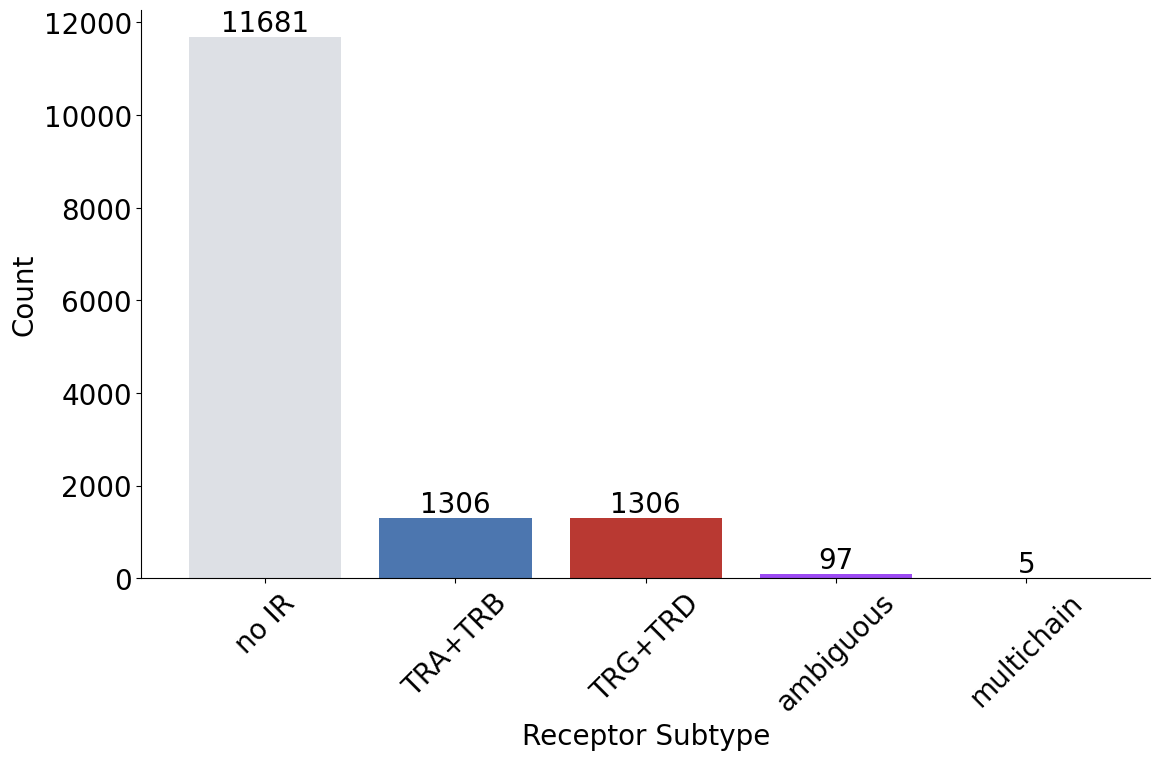

In [12]:
gdT_counts = gdT_adata.obs['receptor_subtype'].value_counts()
colors = [receptor_subtype_palette.get(cat, '#cccccc') for cat in gdT_counts.index]

plt.figure(figsize=(12, 8))
gdT_ax = gdT_counts.plot(
    kind='bar',
    width=0.8,
    color=colors 
)

plt.xlabel('Receptor Subtype', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.xticks(rotation=45, fontsize=20)
plt.yticks(fontsize=20)

gdT_ax.spines['top'].set_visible(False)
gdT_ax.spines['right'].set_visible(False)

for i, v in enumerate(gdT_counts):
    gdT_ax.text(i, v, str(v), ha='center', va='bottom', fontsize=20)

plt.tight_layout()
plt.show()

In [13]:
is_gdT_barcodes = set(gdT_adata.obs.index[gdT_adata.obs['receptor_subtype'] == 'TRG+TRD'])
is_abT_barcodes = set(abT_adata.obs.index[abT_adata.obs['receptor_subtype'] == 'TRA+TRB'])

atlas_adata.obs['ab_Tcell'] = atlas_adata.obs.index.isin(is_abT_barcodes)
atlas_adata.obs['gd_Tcell'] = atlas_adata.obs.index.isin(is_gdT_barcodes)

atlas_adata.obs['label'] = 'None'
atlas_adata.obs.loc[(atlas_adata.obs['ab_Tcell']) & (~atlas_adata.obs['gd_Tcell']),'label'] = 'abT'
atlas_adata.obs.loc[(~atlas_adata.obs['ab_Tcell']) & (atlas_adata.obs['gd_Tcell']),'label'] = 'gdT'
atlas_adata.obs.loc[(atlas_adata.obs['ab_Tcell']) & (atlas_adata.obs['gd_Tcell']),'label'] = 'Both'

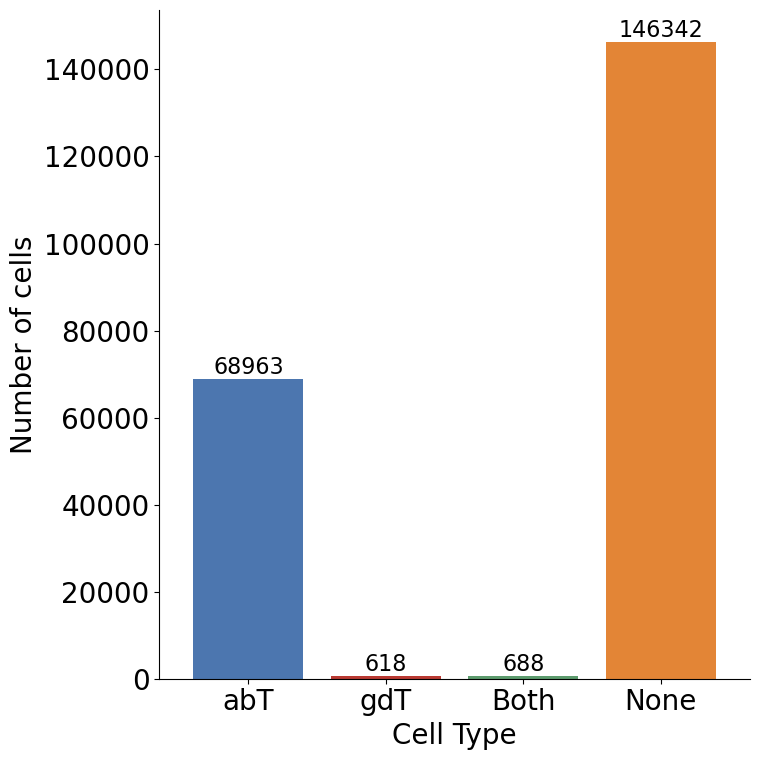

In [14]:
counts = atlas_adata.obs['label'].value_counts().reindex(['abT', 'gdT', 'Both', 'None'])

plt.figure(figsize=(8, 8))

ax = counts.plot(
    kind='bar',
    color=['#4c76af', '#b93932', '#5c9b6d', '#e38536'], 
    width=0.8
)

plt.ylabel('Number of cells', fontsize=20)
plt.xlabel('Cell Type', fontsize=20)
plt.xticks(rotation=0, fontsize=20)
plt.yticks(fontsize=20)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=16)

plt.tight_layout()
plt.show()

Pool the raw data

In [ ]:
adata_list = []

for i in range(1, 5):
    _adata = sc.read_10x_mtx(
        SONG_base / f"hd{i}" / "filtered_feature_bc_matrix",
        var_names='gene_symbols',
        cache=False
    )

    _df_ab = pd.read_csv(SONG_base / f"hd{i}" / "ab_tcr_filtered_contig_annotations.csv")
    abT = np.array(np.unique(_df_ab.barcode[_df_ab['productive'] == True]))
    idx = hilearn.match(abT, _adata.obs.index)
    idx1 = np.where(idx != None)[0]
    idx2 = idx[idx1].astype(int)
    _adata.obs['ab_Tcell'] = [False] * _adata.shape[0]
    _adata.obs['ab_Tcell'].values[idx2] = True

    _df_gd = pd.read_csv(SONG_base / f"hd{i}" / "gd_tcr_filtered_contig_annotations.csv")
    gdT = np.array(np.unique(_df_gd.barcode[_df_gd['productive'] == True]))
    idx = hilearn.match(gdT, _adata.obs.index)
    idx1 = np.where(idx != None)[0]
    idx2 = idx[idx1].astype(int)
    _adata.obs['gd_Tcell'] = [False] * _adata.shape[0]
    _adata.obs['gd_Tcell'].values[idx2] = True

    _adata.obs['donor'] = f'hd{i}'
    _adata.obs['organ'] = 'pbmc'
    
    _adata.obs.index = [x + f'.{i}' for x in _adata.obs.index]
    
    adata_list.append(_adata.copy())

SONG Data Visualization

In [ ]:
adata = sc.concat(adata_list)   
adata.obs['donor'] = ['hd' + x.split('.')[1] for x in adata.obs.index]
adata.obs['label'] = ["None"] * adata.shape[0]
adata.obs.loc[adata.obs['ab_Tcell'] * ~adata.obs['gd_Tcell'], 'label'] = 'abT'
adata.obs.loc[adata.obs['gd_Tcell'] * ~adata.obs['ab_Tcell'], 'label'] = 'gdT'
adata.obs.loc[adata.obs['ab_Tcell'] * adata.obs['gd_Tcell'], 'label'] = 'Both'

(array(['Both', 'None', 'abT', 'gdT'], dtype=object),
 array([  307,  1899, 22639,  1847], dtype=int64))

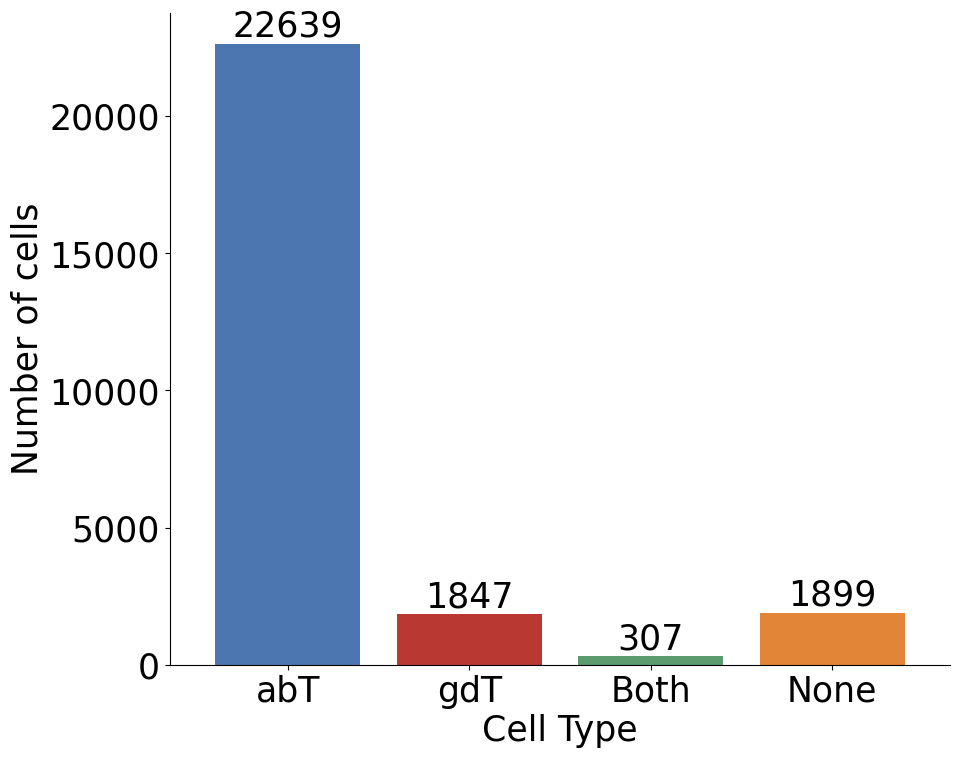

In [ ]:
counts = adata.obs['label'].value_counts().reindex(['abT', 'gdT', 'Both', 'None'])

plt.figure(figsize=(10, 8))

ax = counts.plot(
    kind='bar',
    color=['#4c76af', '#b93932', '#5c9b6d', '#e38536'], 
    width=0.8
)

plt.xlabel('Cell Type', fontsize=25)
plt.ylabel('Number of cells', fontsize=25)
plt.xticks(rotation=0, fontsize=25)
plt.yticks(fontsize=25)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=25)

plt.tight_layout()
plt.show()

In [29]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

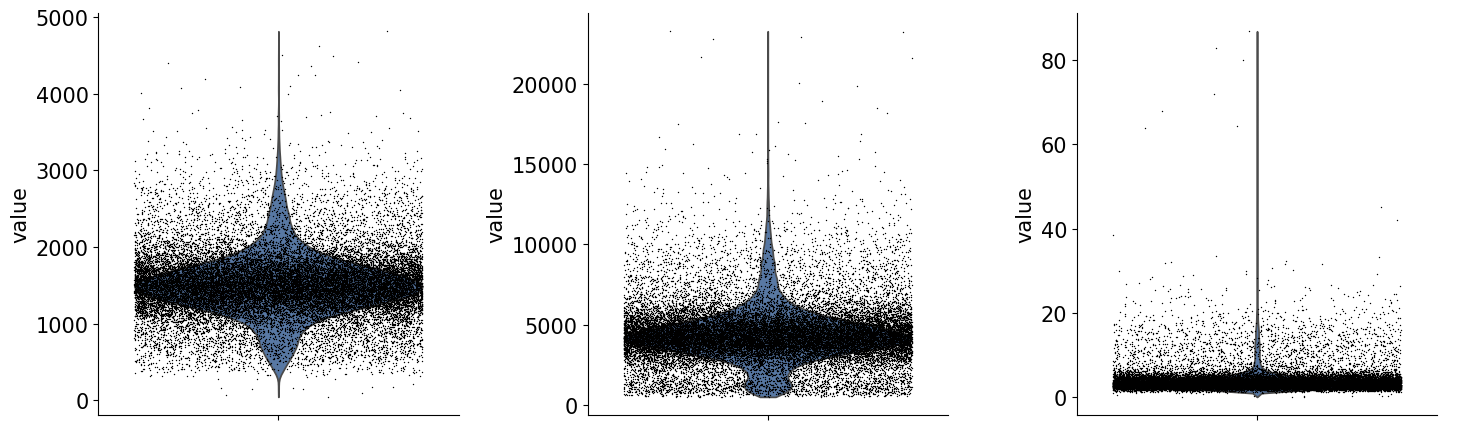

In [30]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    color='#4c76af',
    show=False
)

fig = plt.gcf()
axs = fig.axes

for ax in axs:
    ax.set_xlabel(ax.get_xlabel(), fontsize=15)
    ax.set_ylabel(ax.get_ylabel(), fontsize=15)
    ax.tick_params(axis='both', labelsize=15)
    ax.set_title("")

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.show()

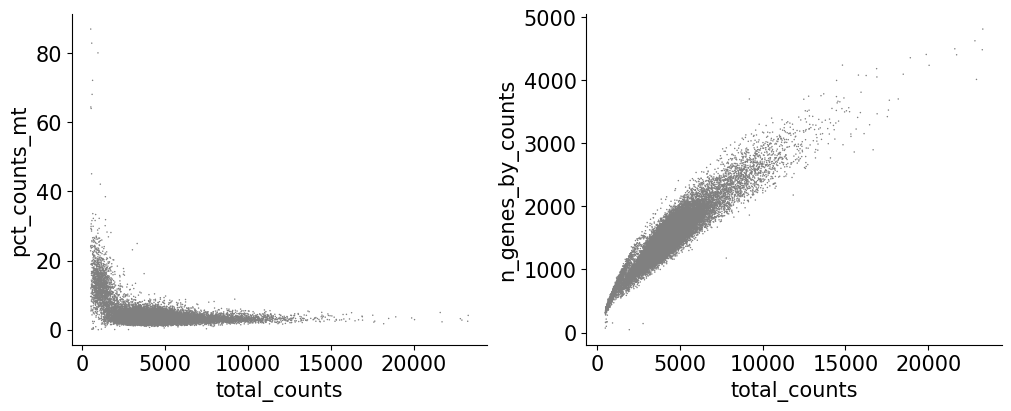

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")

sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt", show=False, ax=axs[0])
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", show=False, ax=axs[1])

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_xlabel(ax.get_xlabel(), fontsize=15)
    ax.set_ylabel(ax.get_ylabel(), fontsize=15)
    ax.tick_params(axis='both', labelsize=15)

plt.show()

In [ ]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5,
    flavor="seurat_v3",
)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)


c:\Users\jysje\anaconda3\envs\scanpy_env\Lib\site-packages\legacy_api_wrap\__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


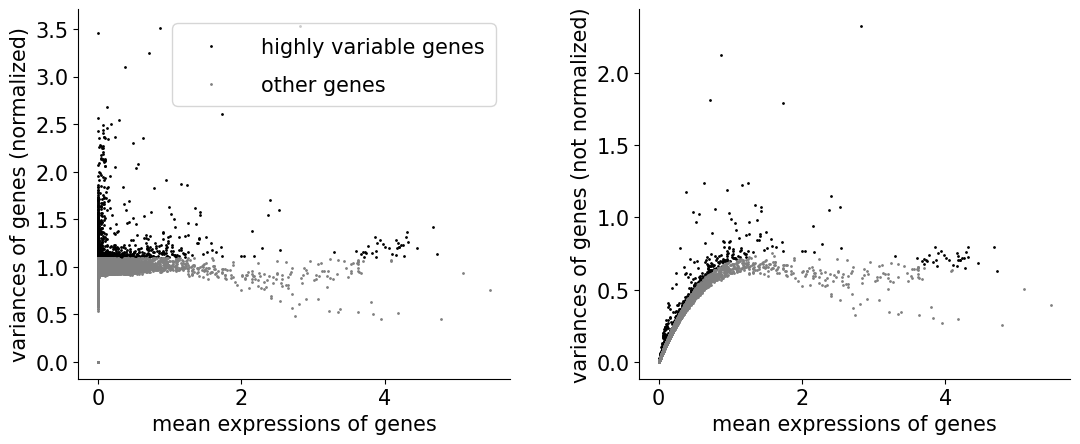

In [33]:
sc.pl.highly_variable_genes(adata, show=False)

fig = plt.gcf()
axs = fig.axes

for ax in axs:
    ax.set_xlabel(ax.get_xlabel(), fontsize=15)
    ax.set_ylabel(ax.get_ylabel(), fontsize=15)
    ax.tick_params(axis='both', labelsize=15)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in axs:
    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(15)

plt.show()

In [34]:
sc.pp.pca(adata, layer=None, svd_solver="arpack")

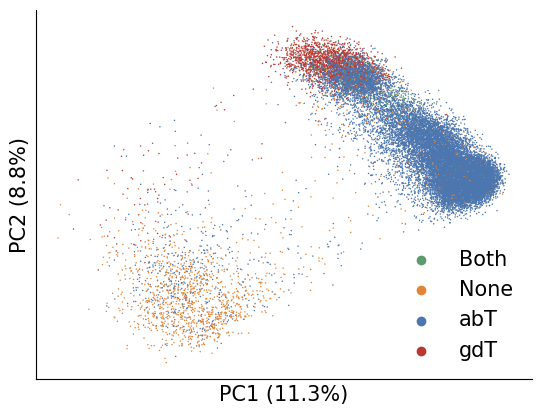

In [ ]:
ax = sc.pl.pca(
    adata,
    annotate_var_explained=True,
    color="label",
    palette=t_cell_type_palette,
    show=False
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel(round_label(ax.get_xlabel()), fontsize=15)
ax.set_ylabel(round_label(ax.get_ylabel()), fontsize=15)

ax.set_title("")
ax.tick_params(axis='both', labelsize=15)

ax.legend(loc='lower right',fontsize=15,frameon=False)

plt.show()

In [37]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)

c:\Users\jysje\anaconda3\envs\scanpy_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


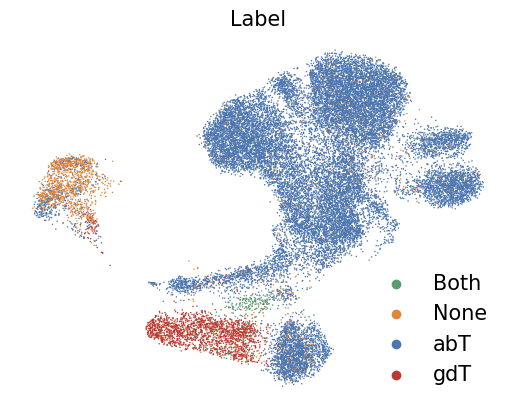

In [38]:
ax = sc.pl.umap(adata, 
           color="label", 
           title=None, 
           palette=t_cell_type_palette,
           legend_loc="right margin",
           legend_fontsize=15, 
           legend_fontoutline=0,
           frameon=False, 
           show=False
           )

ax.set_title('Label', fontsize=15)
ax.legend(
    loc='lower right',
    fontsize=15,
    frameon=False
)
plt.show()

Pool the raw data 

In [ ]:
# adata.write_h5ad(r"C:\Users\jysje\Downloads\analysis\song_atlas_tcells_filtered.h5ad")

See the adata

In [ ]:
adata = sc.read_h5ad(r"C:\Users\jysje\Downloads\analysis\song_atlas_tcells_filtered.h5ad")

np.random.seed(42)

Read the data

Cell and Gene Structural Filtering

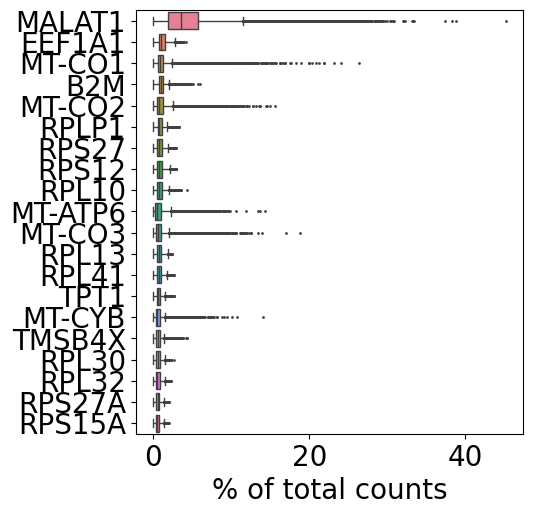

In [ ]:
adata.var_names_make_unique()
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

sc.pl.highest_expr_genes(adata, n_top=20)

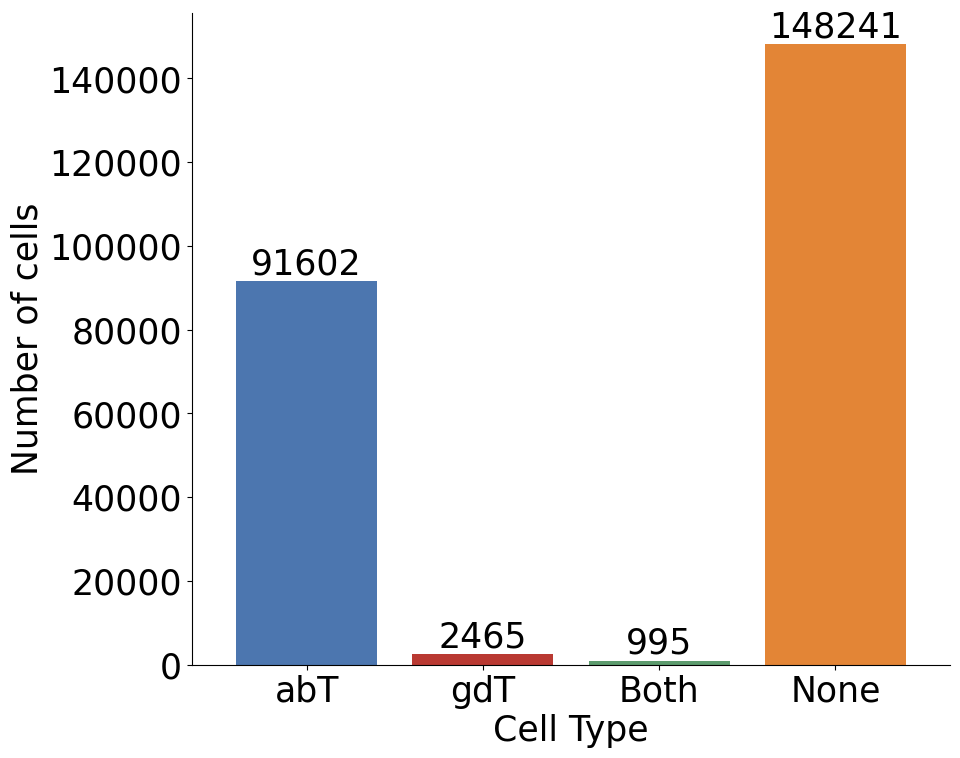

In [ ]:
counts = adata.obs['label'].value_counts()
counts = counts.reindex(['abT', 'gdT', 'Both', 'None'])

plt.figure(figsize=(10, 8))

ax = counts.plot(
    kind='bar',
    color=['#4c76af', '#b93932', '#5c9b6d', '#e38536'], 
    width=0.8
)

plt.xlabel('Cell Type', fontsize=25)
plt.ylabel('Number of cells', fontsize=25)
plt.xticks(rotation=0, fontsize=25)
plt.yticks(fontsize=25)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=25)

plt.tight_layout()
plt.show()

In [45]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

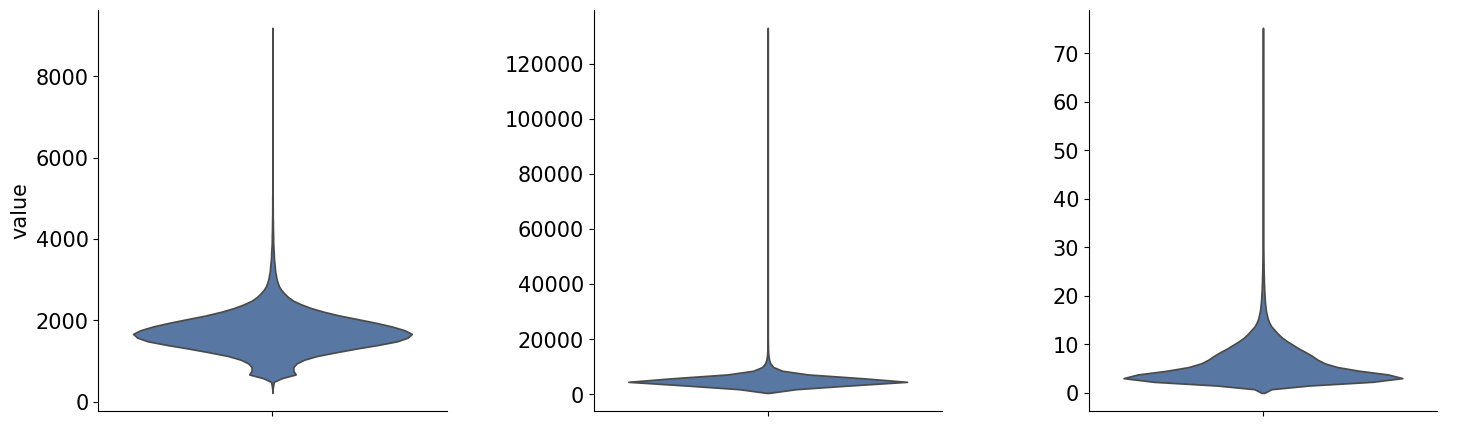

In [46]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    stripplot=False,
    multi_panel=True,
    color='#4c76af',
    show=False
)

fig = plt.gcf()
axs = fig.axes

for ax in axs:
    ax.set_xlabel(ax.get_xlabel(), fontsize=15)
    ax.set_ylabel(ax.get_ylabel(), fontsize=15)
    ax.tick_params(axis='both', labelsize=15)
    ax.set_title("")

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.show()

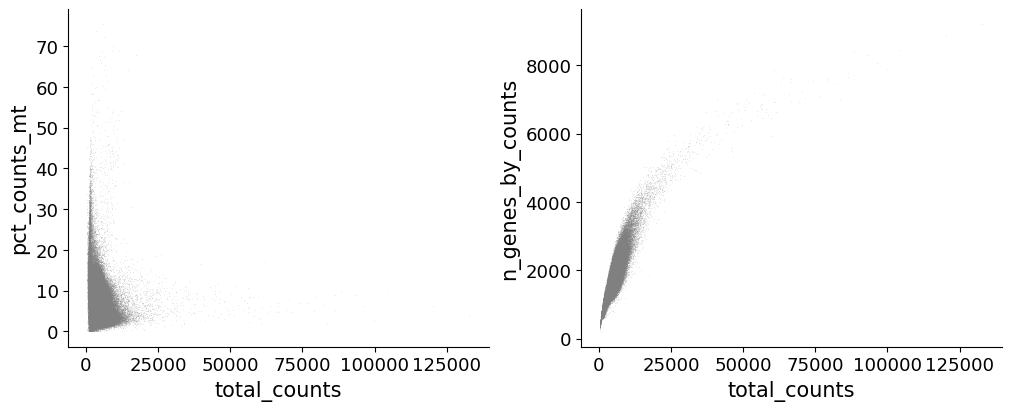

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")

sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt", show=False, ax=axs[0])
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", show=False, ax=axs[1])

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_xlabel(ax.get_xlabel(), fontsize=15)
    ax.set_ylabel(ax.get_ylabel(), fontsize=15)
    ax.tick_params(axis='both', labelsize=13)

plt.show()

In [ ]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5, 
    flavor="seurat_v3",
)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

c:\Users\jysje\anaconda3\envs\scanpy_env\Lib\site-packages\legacy_api_wrap\__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


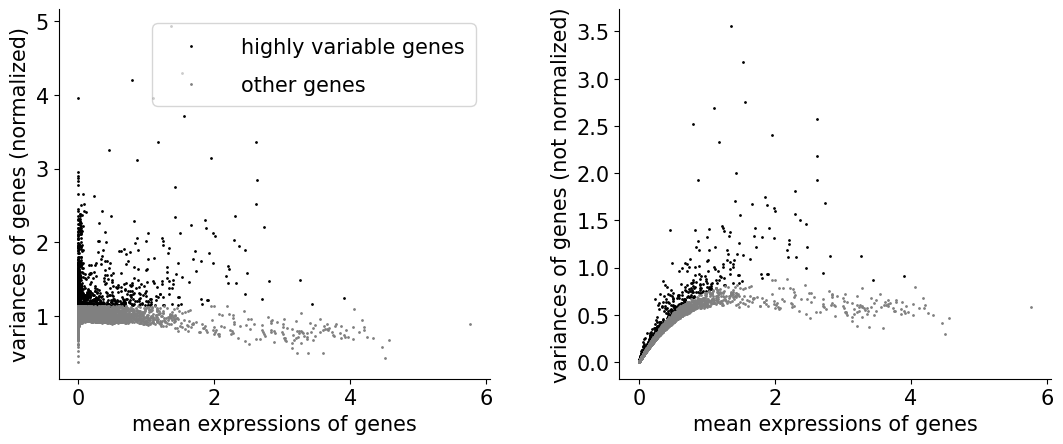

In [49]:
sc.pl.highly_variable_genes(adata, show=False)

fig = plt.gcf()
axs = fig.axes

for ax in axs:
    ax.set_xlabel(ax.get_xlabel(), fontsize=15)
    ax.set_ylabel(ax.get_ylabel(), fontsize=15)
    ax.tick_params(axis='both', labelsize=15)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for ax in axs:
    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(15)

plt.show()

In [50]:
sc.pp.pca(adata, layer=None, svd_solver="arpack")

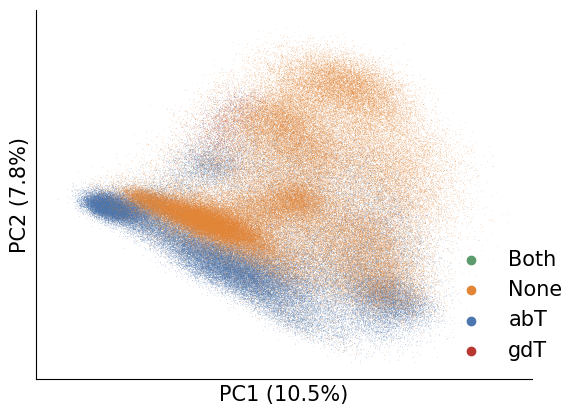

In [ ]:
ax = sc.pl.pca(
    adata,
    annotate_var_explained=True,
    color="label",
    palette=t_cell_type_palette,
    show=False
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_xlabel(round_label(ax.get_xlabel()), fontsize=15)
ax.set_ylabel(round_label(ax.get_ylabel()), fontsize=15)

ax.set_title("")
ax.tick_params(axis='both', labelsize=15)

ax.legend(
    loc='lower right',
    bbox_to_anchor=(1.1, 0.0), 
    fontsize=15,
    frameon=False
)

plt.show()

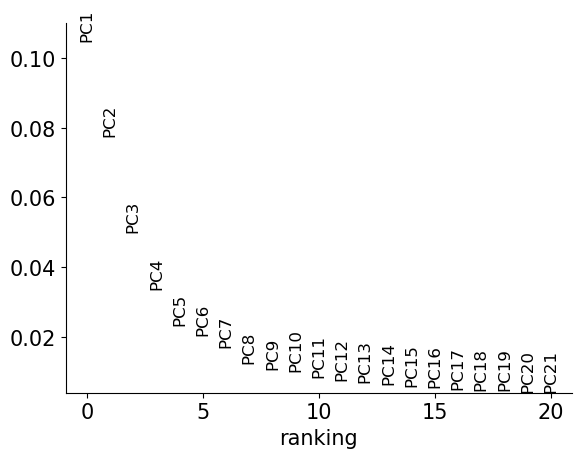

In [52]:
sc.pl.pca_variance_ratio(adata, n_pcs=20, show=False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel(ax.get_xlabel(), fontsize=15)
ax.set_ylabel(ax.get_ylabel(), fontsize=15)
ax.set_title("")
ax.tick_params(axis='both', labelsize=15)

for text in ax.texts:
    text.set_fontsize(12)

plt.show()

In [53]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata, random_state=42)

KeyboardInterrupt: 

In [ ]:
ax = sc.pl.umap(adata, 
           color="label", # donor, organ, label
           palette=t_cell_type_palette,
           legend_fontoutline=0,
           frameon=False, 
           show=False
           )

ax.legend(
    loc='lower right',
    bbox_to_anchor=(1.1, 0.0), 
    fontsize=8,
    frameon=False
)

ax.set_title('Label', fontsize=15)
plt.show()

In [ ]:
adata.obs['dataset_split'] = 'Test atlas'
adata.obs.loc[adata.obs['organ'] == 'pbmc', 'dataset_split'] = 'Train'

In [ ]:
ax = sc.pl.umap(
    adata,
    color='dataset_split',
    palette=palette_split,
    legend_fontoutline=0,
    frameon=False,
    show=False
)

ax.legend(
    loc='lower right',
    bbox_to_anchor=(1.1, 0.0),
    fontsize=8,
    frameon=False
)

ax.set_title('Dataset Split', fontsize=15)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])

plt.show()

SONG prediction LOGO

In [ ]:
song_idx = adata.obs['organ'] == 'pbmc'
adata_song = adata[song_idx, :].copy()

In [ ]:
idx = (adata_song.obs['label'] == 'abT') + (adata_song.obs['label'] == 'gdT')

adata_use_song = adata_song[idx > 0, :].copy()

In [ ]:
X = adata_use_song.obsm['X_pca']
y = adata_use_song.obs['label'] == 'gdT'
groups = adata_use_song.obs['donor']

In [ ]:
clf = LogisticRegression(max_iter=300)
logo = LeaveOneGroupOut()

y_pred_proba_cv = cross_val_predict(
    clf,
    X,
    y,
    cv=logo,
    groups=groups,
    method='predict_proba'
)

P_hat_prob_cv = y_pred_proba_cv[:, 1]

In [ ]:
fpr_cv, tpr_cv, thresholds_cv = metrics.roc_curve(y, P_hat_prob_cv)
roc_auc_cv = metrics.roc_auc_score(y, P_hat_prob_cv)

In [ ]:
fig = plt.figure(dpi=70)
plt.plot(fpr_cv, tpr_cv, label='AUC=%.3f' % (roc_auc_cv))
plt.grid(False)
plt.xlabel("False Positive Rate", fontsize=15)
plt.ylabel("True Positive Rate", fontsize=15)
plt.title("")
plt.legend(fontsize=15, frameon=False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=15)
plt.show()

In [ ]:
for i in np.unique(groups):
    idx0 = groups == i
    auc_i = metrics.roc_auc_score(y[idx0], P_hat_prob_cv[idx0])

LOGO on Altas (Leave One Donor Out)

In [ ]:
atlas_idx = adata.obs['organ'] != 'pbmc'
adata_atlas = adata[atlas_idx, :].copy()

In [ ]:
idx = (adata_atlas.obs['label'] == 'abT') | (adata_atlas.obs['label'] == 'gdT')

adata_use_atlas = adata_atlas[idx, :].copy()

In [ ]:
X_atlas = adata_use_atlas.obsm['X_pca']
y_atlas = adata_use_atlas.obs['label'] == 'gdT'
groups_atlas = adata_use_atlas.obs['donor']

In [ ]:
y_pred_proba_cv_atlas_donor = cross_val_predict(
    clf,
    X_atlas,
    y_atlas,
    cv=logo,
    groups=groups_atlas,
    method='predict_proba'
)

P_hat_prob_cv_atlas_donor = y_pred_proba_cv_atlas_donor[:, 1]

In [ ]:
fpr_atlas_donor, tpr_atlas_donor, thresholds_atlas_donor = metrics.roc_curve(
    y_atlas, P_hat_prob_cv_atlas_donor
)
auc_atlas_donor = metrics.roc_auc_score(y_atlas, P_hat_prob_cv_atlas_donor)


In [ ]:
fig = plt.figure(dpi=70)
plt.plot(fpr_atlas_donor, tpr_atlas_donor, label='AUC=%.3f' % auc_atlas_donor)
plt.grid(False)
plt.xlabel("False Positive Rate", fontsize=15)
plt.ylabel("True Positive Rate", fontsize=15)
plt.title("")
plt.legend(fontsize=15, frameon=False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=15)
plt.show()

LOGO on Altas (Leave One Organ Out)

In [ ]:
groups_organ_atlas = adata_use_atlas.obs['organ']

In [ ]:
y_pred_proba_cv_atlas_organ = cross_val_predict(
    clf,
    X_atlas,
    y_atlas,
    cv=logo,
    groups=groups_organ_atlas,
    method='predict_proba'
)

P_hat_prob_cv_atlas_organ = y_pred_proba_cv_atlas_organ[:, 1]

In [ ]:
fpr_atlas_organ, tpr_atlas_organ, thresholds_atlas_organ = metrics.roc_curve(
    y_atlas, P_hat_prob_cv_atlas_organ
)
auc_atlas_organ = metrics.roc_auc_score(y_atlas, P_hat_prob_cv_atlas_organ)


In [ ]:
fig = plt.figure(dpi=70)
plt.plot(fpr_atlas_organ, tpr_atlas_organ, label='AUC=%.3f' % auc_atlas_organ)
plt.grid(False)
plt.xlabel("False Positive Rate", fontsize=15)
plt.ylabel("True Positive Rate", fontsize=15)
plt.title("")
plt.legend(fontsize=15, frameon=False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=15)
plt.show()

In [ ]:
clf = LogisticRegression(max_iter=300)
clf.fit(X, y)

In [ ]:
X_atlas = adata_atlas.obsm['X_pca']
P_hat_prob_atlas = clf.predict_proba(X_atlas)[:, 1]

adata_atlas.obs['gdT_prob'] = P_hat_prob_atlas

In [ ]:
# Compare with manual annotations in atlas 
idx_eval = (adata_atlas.obs['label'] == 'abT') + (adata_atlas.obs['label'] == 'gdT')
adata_eval = adata_atlas[idx_eval > 0, :].copy()

y_eval = adata_eval.obs['label'] == 'gdT'
P_hat_prob_eval = adata_eval.obs['gdT_prob'].values

In [ ]:
baseline = np.mean(y_eval)

In [ ]:
# Compute precision-recall
precision, recall, thresholds_pr = precision_recall_curve(y_eval, P_hat_prob_eval)

# Average precision (AUC for PR curve)
ap_score = average_precision_score(y_eval, P_hat_prob_eval)

# Plot
plt.figure()
plt.plot(recall, precision, label=f'PR curve (AP = {ap_score:.3f})')
plt.axhline(y=baseline, linestyle='--', label=f'Baseline ({baseline:.3f})')
plt.xlabel('Recall', fontsize=15)
plt.ylabel('Precision', fontsize=15)
plt.title('')
plt.grid(False)

pr_ax = plt.gca()
pr_ax.spines['top'].set_visible(False)
pr_ax.spines['right'].set_visible(False)
pr_ax.tick_params(axis='both', labelsize=12)
pr_ax.legend(fontsize=12, frameon=False)

plt.show()

In [ ]:
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds_pr[best_idx]

In [ ]:
adata_atlas.obs['gdT_pred'] = adata_atlas.obs['gdT_prob'] > best_threshold

In [ ]:
fpr_eval, tpr_eval, thresholds_eval = metrics.roc_curve(y_eval, P_hat_prob_eval)
roc_auc_eval = metrics.roc_auc_score(y_eval, P_hat_prob_eval)

In [ ]:
fig = plt.figure(dpi=70)
plt.plot(fpr_eval, tpr_eval, label='AUC=%.3f' % (roc_auc_eval))
plt.grid(False)
plt.xlabel("False Positive Rate", fontsize=15)
plt.ylabel("True Positive Rate", fontsize=15)
plt.title("")
plt.legend(fontsize=15, frameon=False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=15)
plt.show()

In [ ]:
roc_results = [
    (fpr_cv, tpr_cv, roc_auc_cv, "Training Donor LOGO"),
    (fpr_atlas_donor, tpr_atlas_donor, auc_atlas_donor, "Atlas Donor LOGO"),
    (fpr_atlas_organ, tpr_atlas_organ, auc_atlas_organ, "Atlas Organ LOGO"),
    (fpr_eval, tpr_eval, roc_auc_eval, "External Validation")
]

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(8, 7), constrained_layout=True)

axs = axs.flatten()

for i, (fpr, tpr, auc, title) in enumerate(roc_results):
    ax = axs[i]
    
    ax.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)
    
    ax.tick_params(axis='both', labelsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=12, frameon=False)

fig.supxlabel("False Positive Rate", fontsize=15)
fig.supylabel("True Positive Rate", fontsize=15)

plt.show()

In [ ]:
y_eval_pred = P_hat_prob_eval > best_threshold
cm = confusion_matrix(y_eval, y_eval_pred)
labels = ['abT', 'gdT'] 

plt.rcParams.update({'font.size': 15})

plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("")
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
adata_eval = adata_use_atlas.copy()
adata_eval.obs['gdT_prob'] = P_hat_prob_eval

plt.figure(figsize=(6,4))
sns.histplot(
    data=adata_eval.obs,
    x='gdT_prob',
    hue='label',
    bins=40,
    stat='density',
    common_norm=False,
    edgecolor=None, 
    alpha=1
)
plt.title('Probability separation: gdT vs abT (SONG CV)')
sns.despine()
plt.show()

In [ ]:
# Define thresholds
low_thresh = 0.1
high_thresh = 0.9

low_prob = adata_eval.obs[adata_eval.obs['gdT_prob'] < low_thresh]
high_prob = adata_eval.obs[adata_eval.obs['gdT_prob'] > high_thresh]

n_total = len(adata_eval.obs)
n_low = len(low_prob)
n_high = len(high_prob)


low_counts = low_prob['label'].value_counts()
high_counts = high_prob['label'].value_counts()

low_pct = low_counts / n_low
high_pct = high_counts / n_high

summary = pd.DataFrame({
    '<0.1_count': low_counts,
    '<0.1_pct': low_pct,
    '>0.9_count': high_counts,
    '>0.9_pct': high_pct
}).fillna(0)

summary['<0.1_pct'] = summary['<0.1_pct'].map(lambda x: f"{x:.2%}")
summary['>0.9_pct'] = summary['>0.9_pct'].map(lambda x: f"{x:.2%}")


In [ ]:
adata_song_eval = adata_use.copy()
adata_song_eval.obs['gdT_prob'] = P_hat_prob_cv

In [ ]:
plt.figure(figsize=(5,4))
sns.boxplot(
    data=adata_song_eval.obs,
    x='label',
    y='gdT_prob', 
    showfliers=False
)
plt.title('gdT probability by true label')
plt.show()

In [ ]:
adata.obs['gdT_prob_song'] = np.nan
adata.obs.loc[adata_use.obs.index, 'gdT_prob_song'] = P_hat_prob_cv

In [ ]:
cmap = LinearSegmentedColormap.from_list(
    "gdT_abT",
    ["#4c76af","#b93932"]  
)

In [ ]:
adata_atlas_eval = adata_atlas[adata_atlas.obs['label'].isin(['abT', 'gdT'])].copy()

In [ ]:
fig = sc.pl.umap(
    adata_atlas_eval,
    color='label',
    palette=t_cell_type_palette,
    legend_loc='right margin',
    frameon=False,
    show=False,
    return_fig=True
)

ax = fig.axes[0]

ax.set_title("Label", fontsize=15)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])

ax.legend(
    loc='lower right',
    bbox_to_anchor=(1.1, 0.0), 
    fontsize=15,
    frameon=False
)

plt.show()

In [ ]:
sc.pl.umap(
    adata_atlas_eval,
    color=['gdT_prob'],
    color_map=cmap,  
    vmin=0,
    vmax=1,
    legend_loc='right margin', 
    show=False,
    frameon=False,
    return_fig=True
)

umap_gdT_abT_ax = plt.gca()

umap_gdT_abT_ax.set_xlabel("")
umap_gdT_abT_ax.set_ylabel("")
umap_gdT_abT_ax.set_title("Predicted gdT Probability", fontsize=15)

plt.show()

In [ ]:
sc.pl.umap(
    adata,
    color='gdT_prob_song',
    vmin=0,
    vmax=1,
    color_map=cmap,
    show=False
)

ax = plt.gca()

# Remove top & right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title("")

plt.show()

In [ ]:
adata.obs['gdT_prob_atlas'] = np.nan
adata.obs.loc[adata_atlas.obs.index, 'gdT_prob_atlas'] = P_hat_prob_atlas

In [ ]:
sc.pl.umap(
    adata,
    color='gdT_prob_atlas',
    vmin=0,
    vmax=1,
    color_map=cmap,
    show=False
)

ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title("")

plt.show()

In [ ]:
sc.pl.umap(adata, color='label', vmin=0, vmax=1)

In [ ]:
sc.pl.umap(adata, color='organ', vmin=0, vmax=1)

In [ ]:
# SONG 

y_true = adata_song_eval.obs['label'] == 'gdT'
y_pred = adata_song_eval.obs['gdT_prob'] > 0.5


In [ ]:
adata_atlas_eval = adata_atlas.copy()

idx_eval = (adata_atlas_eval.obs['label'] == 'abT') + (adata_atlas_eval.obs['label'] == 'gdT')
adata_atlas_eval = adata_atlas_eval[idx_eval > 0, :].copy()

In [ ]:
for tissue in np.unique(adata_atlas_eval.obs['organ']):
    idx = adata_atlas_eval.obs['organ'] == tissue
    
    if np.sum(idx) > 20:
        y_true = adata_atlas_eval.obs.loc[idx, 'label'] == 'gdT'
        y_prob = adata_atlas_eval.obs.loc[idx, 'gdT_prob']
        
        auc = roc_auc_score(y_true, y_prob)

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(
    data=adata_atlas_eval.obs,
    x='organ',
    y='gdT_prob',
    hue='label', 
    showfliers=False
)
plt.xticks(rotation=45)
plt.title('Prediction distribution by tissue')
plt.show()

In [ ]:
adata_song_eval.obs['error'] = (
    (adata_song_eval.obs['gdT_prob'] > 0.5) != 
    (adata_song_eval.obs['label'] == 'gdT')
)

In [ ]:
adata.obs['error'] = False
adata.obs.loc[adata_song_eval.obs.index, 'error'] = adata_song_eval.obs['error']

sc.pl.umap(adata, color=['error'])

In [ ]:
adata_song_eval.obs.loc[adata_song_eval.obs['error'], 'label'].value_counts()

Testing on no IR data

In [ ]:
none_barcodes = adata.obs.index[(adata.obs['label'] == 'None') & (adata.obs['organ'] != 'pbmc')]

In [ ]:
adata_none = adata[none_barcodes, :].copy()
X_none = adata_none.obsm['X_pca']
P_hat_prob_none = clf.predict_proba(X_none)[:, 1]
adata_none.obs['gdT_prob'] = P_hat_prob_none
adata_none.obs['gdT_pred'] = P_hat_prob_none > best_threshold 

In [ ]:
data = adata_none.obs['gdT_prob']

# Histogram
counts, bins = np.histogram(data, bins=50)

# Normalize based on probability (IMPORTANT)
norm = plt.Normalize(0, 1)

plt.figure()

for i in range(len(counts)):
    plt.bar(
        bins[i],
        counts[i],
        width=bins[i+1] - bins[i],
        color=cmap(norm(bins[i])),  # color based on probability
        align='edge'
    )

# Styling
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel("Predicted gdT probability", fontsize=15)
ax.set_ylabel("Count", fontsize=15)

plt.title("")
plt.show()

In [ ]:
sc.pl.umap(
    adata_none,
    color=['gdT_prob'],
    color_map=cmap,  
    vmin=0,
    vmax=1,
    legend_loc='right margin', 
    show=False,
    frameon=False,
    return_fig=True
)

umap_gdT_abT_ax = plt.gca()

umap_gdT_abT_ax.set_xlabel("")
umap_gdT_abT_ax.set_ylabel("")
umap_gdT_abT_ax.set_title("")

plt.show()

In [ ]:
adata_none.obs['gdT_prob'].describe()

In [ ]:
adata_none.obs['gdT_pred'].mean()